# Fama-French Five-Factor Benchmark
Cross-sectional equity return prediction in the Emerging Markets universe. The five Fama-French factor proxies used are book-to-market (value), operating profitability divided by book equity (profitability), asset growth (investment), past 12-month returns (momentum), and market equity (size).

Three types of portfolios are computed. First, a value-weighted market portfolio is reported as the long-only. Second, single-factor quintile portfolios are constructed for each of the five factors in both long-short and long-only form. Third, the Fama-MacBeth cross-sectional regression is estimated on the same five factor proxies, and an out-of-sample predictive portfolio is constructed from the expanding-window slope coefficients, again in both long-short and long-only form.

All portfolios use the same three-month rebalancing schedule, 25 basis-point transaction cost, and volatility overlay. Both Unscaled and volatility-targeted Sharpe ratios are saved.

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import spearmanr

warnings.filterwarnings('ignore')

In [2]:
# configuration

data_path = Path('../data/Global Factor_EM.parquet')
results_dir = Path('../results/benchmark/ff_benchmark')
results_dir.mkdir(parents = True, exist_ok = True)

# jkp column names for the five fama-french factor proxies
char_map = {
    'value': 'be_me',
    'profitability': 'ope_be',
    'investment': 'at_gr1',
    'momentum': 'ret_12_1',
    'size': 'me',
}
fm_chars = list(char_map.values())

ret_col = 'ret_exc_lead1m'
rebalance_freq = 3
tc_bps = 25
min_stocks = 30
ret_clip_low = -1.0
ret_clip_high = 1.0

target_vol = 0.10
vol_lookback = 6
max_leverage_ls = 3.0
max_leverage_lo = 3.0

id_cols = ['id', 'eom', 'excntry', ret_col, 'me']

# all reported metrics are computed on the test window of jan 2021 onward,
# matching the test window used by the tree, ft, and mlp benchmarks.
# the volatility overlay is applied to the full sample so the trailing
# window estimator has proper warm up history before the test window.
test_start = pd.Timestamp('2021-01-01')


### Load and process

In [3]:

schema = pq.read_schema(data_path)
all_col_names = schema.names

factor_cols = list(char_map.values())
fm_available = [c for c in fm_chars if c in all_col_names]
all_chars = list(dict.fromkeys(factor_cols + fm_available))
needed = list(dict.fromkeys([c for c in id_cols + all_chars if c in all_col_names]))

df = pd.read_parquet(data_path, columns = needed)
df['eom'] = pd.to_datetime(df['eom'])

print(f'rows loaded, {df.shape[0]:,}')
print(f'columns loaded, {df.shape[1]}')
print(f'date range, {df["eom"].min().date()} to {df["eom"].max().date()}')

for col in all_chars:
    if col in df.columns and df[col].dtype == np.float64:
        df[col] = df[col].astype(np.float32)
if 'me' in df.columns and df['me'].dtype == np.float64:
    df['me'] = df['me'].astype(np.float32)

df[ret_col] = df[ret_col].clip(lower = ret_clip_low, upper = ret_clip_high)

rows loaded, 4,386,856
columns loaded, 9
date range, 1995-01-31 to 2025-12-31


### Build monthly cross-sections

In [4]:

sorted_eoms = sorted(df['eom'].unique())
all_months = {}

for eom in sorted_eoms:
    month = df[df['eom'] == eom].copy()
    month = month[month[ret_col].notna()]
    if len(month) < min_stocks:
        continue

    entry = {
        'ids': month['id'].values,
        'r': month[ret_col].values.astype(np.float64),
        'me': (month['me'].values.astype(np.float64)
                if 'me' in month.columns else np.ones(len(month))),
    }

    for fname, cname in char_map.items():
        entry[fname] = (month[cname].values.astype(np.float64)
                        if cname in month.columns else np.full(len(month), np.nan))

    fm_vals = {}
    for cname in fm_available:
        vals = (month[cname].values.astype(np.float64)
                if cname in month.columns else np.full(len(month), np.nan))
        valid = np.isfinite(vals)
        ranked = np.zeros(len(month))
        if valid.sum() > 5:
            ranked[valid] = pd.Series(vals[valid]).rank(pct = True).values - 0.5
        fm_vals[cname] = ranked

    entry['fm_x'] = np.column_stack([fm_vals[c] for c in fm_available])
    all_months[eom] = entry

sorted_dates = sorted(all_months.keys())
print(f'processed months, {len(sorted_dates)}')

processed months, 372


In [5]:
def portfolio_metrics(rets):
    rets = np.array(rets, dtype = np.float64)
    if len(rets) == 0:
        return {}
    tw = float((1.0 + rets).prod())
    ann_ret = -1.0 if tw <= 0 else float(tw ** (12.0 / len(rets)) - 1.0)
    ann_vol = float(rets.std() * np.sqrt(12.0))
    sharpe = ann_ret / max(ann_vol, 1e-8)
    se = float(np.sqrt((1.0 + 0.5 * sharpe ** 2) / len(rets)))
    cw = np.cumprod(1.0 + rets)
    pk = np.maximum.accumulate(cw)
    max_dd = float(((pk - cw) / pk).max()) if len(cw) > 0 else 0.0
    return {
        'ann_ret': ann_ret, 'ann_vol': ann_vol, 'sharpe': sharpe,
        'se_sharpe': se, 'max_dd': max_dd, 'n_obs': len(rets),
    }


def apply_vol_target(monthly_rets, rebalance_indices, target_vol, vol_lookback, max_leverage, freq = None):
    if freq is None:
        freq = rebalance_freq
    scaled = np.array(monthly_rets, dtype = np.float64)
    n = len(monthly_rets)
    n_rb = len(rebalance_indices)
    period_rets = []
    for i in range(1, n_rb):
        window = np.array(monthly_rets[rebalance_indices[i - 1]:rebalance_indices[i]])
        period_rets.append(float(np.prod(1.0 + window) - 1.0))
    for i in range(n_rb):
        if i < vol_lookback:
            continue
        rb_idx = rebalance_indices[i]
        lookback_months = vol_lookback * freq
        start_month = max(0, rb_idx - lookback_months)
        trailing = np.array(monthly_rets[start_month:rb_idx], dtype=np.float64)
        if len(trailing) < 2:
            continue
        sigma_ann = float(trailing.std(ddof=1) * np.sqrt(12.0))
        lev = float(np.clip(target_vol / max(sigma_ann, 1e-8), 0.0, max_leverage))
        next_rb = rebalance_indices[i + 1] if i + 1 < n_rb else n
        scaled[rebalance_indices[i]:next_rb] = (
            np.array(monthly_rets[rebalance_indices[i]:next_rb]) * lev
        )
    return scaled

def filter_to_test_window(rets, dates, start_date):
    """Slice a return series to observations whose date is at or after start_date."""
    rets_arr = np.array(rets, dtype = np.float64)
    dates_arr = np.array(dates)
    mask = dates_arr >= start_date
    return rets_arr[mask]


### Market portfolio (value-weighted, long-only by construction)

In [6]:

market_rets = []
market_dates = []
for eom in sorted_dates:
    m = all_months[eom]
    valid = np.isfinite(m['me']) & (m['me'] > 0) & np.isfinite(m['r'])
    if valid.sum() < 5:
        continue
    w = m['me'][valid] / m['me'][valid].sum()
    market_rets.append(float((w * m['r'][valid]).sum()))
    market_dates.append(eom)

market_rets_full = np.array(market_rets)

# the market portfolio is reweighted every month, so each observation is its
# own rebalance for the purposes of the volatility overlay
market_rb_indices = list(range(len(market_rets_full)))
market_scaled_full = apply_vol_target(
    market_rets_full, market_rb_indices, target_vol, vol_lookback, max_leverage_lo, freq = 1,
)

# filter both series to the test window before computing metrics
market_rets = filter_to_test_window(market_rets_full, market_dates, test_start)
market_scaled = filter_to_test_window(market_scaled_full, market_dates, test_start)

mkt_m = portfolio_metrics(market_rets)
mkt_m_scaled = portfolio_metrics(market_scaled)

print(f'market months in test window, {len(market_rets)}')
print(f'market unscaled, sharpe = {mkt_m["sharpe"]:.4f}, ann_ret = {mkt_m["ann_ret"] * 100:.2f}%, ann_vol = {mkt_m["ann_vol"] * 100:.2f}%')
print(f'market scaled, sharpe = {mkt_m_scaled["sharpe"]:.4f}, ann_ret = {mkt_m_scaled["ann_ret"] * 100:.2f}%, ann_vol = {mkt_m_scaled["ann_vol"] * 100:.2f}%')


market months in test window, 60
market unscaled, sharpe = 0.2615, ann_ret = 3.03%, ann_vol = 11.61%
market scaled, sharpe = 0.4633, ann_ret = 7.28%, ann_vol = 15.72%


### Quintile factor portfolios (long-short and long-only)

In [7]:
def quintile_factor(factor_name, reverse = False):
    """
    Build both long-short and long-only quintile portfolios from a single factor.

    Long-short, top quintile (or bottom when reverse) minus opposite quintile.
    Long-only,  top quintile (or bottom when reverse) only.
    Turnover is computed per leg with the long-only counting only the long set.
    """
    rset = set(sorted_dates[::rebalance_freq])
    ls_rets, ls_dates, ls_rb_indices = [], [], []
    lo_rets, lo_dates, lo_rb_indices = [], [], []
    li_ids, si_ids = set(), set()
    prev_li, prev_si = set(), set()

    for eom in sorted_dates:
        m = all_months[eom]
        ids = m['ids']
        r = m['r']
        char_vals = m.get(factor_name)
        if char_vals is None:
            continue

        ls_tcv = 0.0
        lo_tcv = 0.0

        if eom in rset:
            ls_rb_indices.append(len(ls_rets))
            lo_rb_indices.append(len(lo_rets))
            valid = np.isfinite(char_vals)
            if valid.sum() < 10:
                continue
            vi = ids[valid]
            vc = char_vals[valid]
            nq = max(1, int(len(vi) * 0.20))
            so = np.argsort(vc)
            if reverse:
                li_ids = set(vi[so[:nq]].tolist())
                si_ids = set(vi[so[::-1][:nq]].tolist())
            else:
                li_ids = set(vi[so[::-1][:nq]].tolist())
                si_ids = set(vi[so[:nq]].tolist())

            ls_to = (
                len(li_ids - prev_li) + len(prev_li - li_ids)
                + len(si_ids - prev_si) + len(prev_si - si_ids)
            ) / max(nq, 1)
            ls_tcv = ls_to * tc_bps / 10000.0

            lo_to = (
                len(li_ids - prev_li) + len(prev_li - li_ids)
            ) / max(nq, 1)
            lo_tcv = lo_to * tc_bps / 10000.0

            prev_li = li_ids
            prev_si = si_ids

        if not li_ids:
            continue
        il = ids.tolist()
        lr = r[np.array([i in li_ids for i in il])]
        sr = r[np.array([i in si_ids for i in il])]
        lr_mean = float(lr.mean()) if len(lr) > 0 else 0.0
        sr_mean = float(sr.mean()) if len(sr) > 0 else 0.0
        ls_rets.append(lr_mean - sr_mean - ls_tcv)
        ls_dates.append(eom)
        lo_rets.append(lr_mean - lo_tcv)
        lo_dates.append(eom)

    return {
        'long_short': {'returns': np.array(ls_rets), 'dates': ls_dates, 'rb_indices': ls_rb_indices},
        'long_only': {'returns': np.array(lo_rets), 'dates': lo_dates, 'rb_indices': lo_rb_indices},
    }

In [8]:
# run the five factor portfolios and report per factor metrics on the test window

factor_defs = [
    ('value', False), ('momentum', False), ('profitability', False),
    ('investment', True), ('size', True),
]

factor_results = {}
rows_for_table = []

for fname, rev in factor_defs:
    sim = quintile_factor(fname, reverse = rev)
    ls, lo = sim['long_short'], sim['long_only']
    if len(ls['returns']) == 0:
        print(f'factor, {fname}, no data')
        continue
    # vol overlay applied to the full sample so the trailing window estimator
    # has full warm up before the test window starts
    ls_scaled_full = apply_vol_target(ls['returns'], ls['rb_indices'], target_vol, vol_lookback, max_leverage_ls)
    lo_scaled_full = apply_vol_target(lo['returns'], lo['rb_indices'], target_vol, vol_lookback, max_leverage_lo)

    # filter both raw and scaled to the test window
    ls_rets_test = filter_to_test_window(ls['returns'], ls['dates'], test_start)
    lo_rets_test = filter_to_test_window(lo['returns'], lo['dates'], test_start)
    ls_scaled_test = filter_to_test_window(ls_scaled_full, ls['dates'], test_start)
    lo_scaled_test = filter_to_test_window(lo_scaled_full, lo['dates'], test_start)

    factor_results[fname] = {
        'returns_ls_unscaled': ls_rets_test, 'returns_ls_scaled': ls_scaled_test,
        'returns_lo_unscaled': lo_rets_test, 'returns_lo_scaled': lo_scaled_test,
        'metrics_ls_unscaled': portfolio_metrics(ls_rets_test),
        'metrics_ls_scaled': portfolio_metrics(ls_scaled_test),
        'metrics_lo_unscaled': portfolio_metrics(lo_rets_test),
        'metrics_lo_scaled': portfolio_metrics(lo_scaled_test),
    }
    mls = factor_results[fname]['metrics_ls_scaled']
    mlo = factor_results[fname]['metrics_lo_scaled']
    rows_for_table.append({
        'factor': fname,
        'ls_sharpe': round(mls['sharpe'], 4),
        'ls_ann_ret': round(mls['ann_ret'] * 100, 2),
        'ls_ann_vol': round(mls['ann_vol'] * 100, 2),
        'lo_sharpe': round(mlo['sharpe'], 4),
        'lo_ann_ret': round(mlo['ann_ret'] * 100, 2),
        'lo_ann_vol': round(mlo['ann_vol'] * 100, 2),
    })

factor_table = pd.DataFrame(rows_for_table)
print(f'Quintile Factor Portfolios, test window from {test_start.date()}, vol targeted')
print(factor_table.to_string(index = False))


Quintile Factor Portfolios, test window from 2021-01-01, vol targeted
       factor  ls_sharpe  ls_ann_ret  ls_ann_vol  lo_sharpe  lo_ann_ret  lo_ann_vol
        value     1.0799       10.58        9.79     1.1827        9.97        8.43
     momentum     0.5196        5.91       11.38     1.4285       13.62        9.54
profitability     0.1264        1.55       12.27     0.7929        7.03        8.87
   investment     0.9686       11.01       11.37     1.0875        9.43        8.67
         size     1.1450       13.03       11.38     1.6814       15.29        9.09


### Fama-macbeth cross-sectional regression

In [9]:

fm_betas = []
fm_dates_used = []

for eom in sorted_dates:
    m = all_months[eom]
    x = m['fm_x']
    r = m['r']
    valid = np.isfinite(r)
    for j in range(x.shape[1]):
        valid = valid & np.isfinite(x[:, j])
    if valid.sum() < len(fm_available) + 5:
        continue
    x_aug = np.column_stack([np.ones(valid.sum()), x[valid]])
    try:
        beta = np.linalg.lstsq(x_aug, r[valid], rcond = None)[0]
        fm_betas.append(beta)
        fm_dates_used.append(eom)
    except np.linalg.LinAlgError:
        continue

fm_betas = np.array(fm_betas)
n_months_fm = len(fm_betas)
fm_mean = fm_betas.mean(axis = 0)
fm_se = fm_betas.std(axis = 0) / np.sqrt(n_months_fm)
fm_tstat = fm_mean / np.maximum(fm_se, 1e-10)

coef_names = ['intercept'] + fm_available
fm_results_table = []
for i, name in enumerate(coef_names):
    p_val = 2.0 * (1.0 - stats.t.cdf(abs(fm_tstat[i]), df = n_months_fm - 1))
    sig = '***' if p_val < 0.01 else '**' if p_val < 0.05 else '*' if p_val < 0.10 else ''
    fm_results_table.append({
        'variable': name,
        'mean_coef': round(float(fm_mean[i]), 5),
        'se': round(float(fm_se[i]), 5),
        't_stat': round(float(fm_tstat[i]), 4),
        'p_value': round(float(p_val), 4),
        'sig': sig,
    })

fm_coef_df = pd.DataFrame(fm_results_table)
print(f'Fama-MacBeth Regression, {n_months_fm} months, {len(fm_available)} characteristics')
print(fm_coef_df.to_string(index = False))

Fama-MacBeth Regression, 372 months, 5 characteristics
 variable  mean_coef      se  t_stat  p_value sig
intercept    0.00863 0.00301  2.8691   0.0044 ***
    be_me    0.01788 0.00286  6.2484   0.0000 ***
   ope_be    0.01274 0.00193  6.6114   0.0000 ***
   at_gr1   -0.00685 0.00235 -2.9145   0.0038 ***
 ret_12_1    0.01501 0.00416  3.6050   0.0004 ***
       me   -0.01377 0.00305 -4.5188   0.0000 ***


### FM predictive portfolio (long-short and long-only)

In [10]:

min_history = 60
fm_predictions = {}

for t_idx in range(min_history, len(fm_dates_used)):
    beta_avg = fm_betas[:t_idx].mean(axis = 0)
    pred_date = fm_dates_used[t_idx]
    m = all_months[pred_date]
    pred = beta_avg[0] + m['fm_x'] @ beta_avg[1:]
    valid = np.isfinite(pred)
    if valid.sum() < 10:
        continue
    fm_predictions[pred_date] = {
        'w': pred[valid].astype(np.float32),
        'ids': m['ids'][valid],
        'r': m['r'][valid].astype(np.float32),
    }

print(f'FM predictive portfolio months out-of-sample, {len(fm_predictions)}')

# rank correlation computed on the test window only, matching the metric basis
fm_corrs = []
for date_key, p in fm_predictions.items():
    if date_key < test_start:
        continue
    if len(p['w']) < 10:
        continue
    c, _ = spearmanr(p['w'], p['r'])
    if not np.isnan(c):
        fm_corrs.append(float(c))
fm_rc = float(np.mean(fm_corrs)) if fm_corrs else 0.0
print(f'FM rank correlation, {fm_rc:.4f}')

keys_fm = sorted(fm_predictions.keys())
rset_fm = set(keys_fm[::rebalance_freq])

fm_ls_rets, fm_ls_dates, fm_ls_rb_indices = [], [], []
fm_lo_rets, fm_lo_dates, fm_lo_rb_indices = [], [], []
li_ids, si_ids = set(), set()
prev_li, prev_si = set(), set()

for eom in keys_fm:
    p = fm_predictions[eom]
    w = p['w']
    ids = p['ids']
    r = p['r']

    ls_tcv = 0.0
    lo_tcv = 0.0

    if eom in rset_fm:
        fm_ls_rb_indices.append(len(fm_ls_rets))
        fm_lo_rb_indices.append(len(fm_lo_rets))
        nq = max(1, int(len(w) * 0.20))
        so = np.argsort(w)
        li_ids = set(ids[so[::-1][:nq]].tolist())
        si_ids = set(ids[so[:nq]].tolist())

        ls_to = (
            len(li_ids - prev_li) + len(prev_li - li_ids)
            + len(si_ids - prev_si) + len(prev_si - si_ids)
        ) / max(nq, 1)
        ls_tcv = ls_to * tc_bps / 10000.0
        lo_to = (
            len(li_ids - prev_li) + len(prev_li - li_ids)
        ) / max(nq, 1)
        lo_tcv = lo_to * tc_bps / 10000.0

        prev_li = li_ids
        prev_si = si_ids

    if not li_ids:
        continue
    il = ids.tolist()
    lr = r[np.array([i in li_ids for i in il])]
    sr = r[np.array([i in si_ids for i in il])]
    lr_mean = float(lr.mean()) if len(lr) > 0 else 0.0
    sr_mean = float(sr.mean()) if len(sr) > 0 else 0.0
    fm_ls_rets.append(lr_mean - sr_mean - ls_tcv)
    fm_ls_dates.append(eom)
    fm_lo_rets.append(lr_mean - lo_tcv)
    fm_lo_dates.append(eom)

fm_ls_rets_full = np.array(fm_ls_rets)
fm_lo_rets_full = np.array(fm_lo_rets)
fm_ls_scaled_full = apply_vol_target(fm_ls_rets_full, fm_ls_rb_indices, target_vol, vol_lookback, max_leverage_ls)
fm_lo_scaled_full = apply_vol_target(fm_lo_rets_full, fm_lo_rb_indices, target_vol, vol_lookback, max_leverage_lo)

# filter the four series to the test window before computing metrics
fm_ls_rets = filter_to_test_window(fm_ls_rets_full, fm_ls_dates, test_start)
fm_lo_rets = filter_to_test_window(fm_lo_rets_full, fm_lo_dates, test_start)
fm_ls_scaled = filter_to_test_window(fm_ls_scaled_full, fm_ls_dates, test_start)
fm_lo_scaled = filter_to_test_window(fm_lo_scaled_full, fm_lo_dates, test_start)

fm_ls_unscaled_m = portfolio_metrics(fm_ls_rets)
fm_ls_scaled_m = portfolio_metrics(fm_ls_scaled)
fm_lo_unscaled_m = portfolio_metrics(fm_lo_rets)
fm_lo_scaled_m = portfolio_metrics(fm_lo_scaled)

print(f'FM long-short unscaled, sharpe = {fm_ls_unscaled_m["sharpe"]:.4f}')
print(f'FM long-short scaled, sharpe = {fm_ls_scaled_m["sharpe"]:.4f}, ann_ret = {fm_ls_scaled_m["ann_ret"] * 100:.2f}%, ann_vol = {fm_ls_scaled_m["ann_vol"] * 100:.2f}%')
print(f'FM long-only unscaled, sharpe = {fm_lo_unscaled_m["sharpe"]:.4f}')
print(f'FM long-only scaled, sharpe = {fm_lo_scaled_m["sharpe"]:.4f}, ann_ret = {fm_lo_scaled_m["ann_ret"] * 100:.2f}%, ann_vol = {fm_lo_scaled_m["ann_vol"] * 100:.2f}%')

FM predictive portfolio months out-of-sample, 312
FM rank correlation, 0.0410
FM long-short unscaled, sharpe = 1.1931
FM long-short scaled, sharpe = 1.2456, ann_ret = 14.90%, ann_vol = 11.96%
FM long-only unscaled, sharpe = 2.1303
FM long-only scaled, sharpe = 1.8946, ann_ret = 16.54%, ann_vol = 8.73%


### Save Results

In [11]:
for fname, fr in factor_results.items():
    np.save(results_dir / f'{fname}_returns_ls_unscaled.npy', fr['returns_ls_unscaled'])
    np.save(results_dir / f'{fname}_returns_ls_scaled.npy', fr['returns_ls_scaled'])
    np.save(results_dir / f'{fname}_returns_lo_unscaled.npy', fr['returns_lo_unscaled'])
    np.save(results_dir / f'{fname}_returns_lo_scaled.npy', fr['returns_lo_scaled'])

np.save(results_dir / 'market_returns.npy', market_rets)
np.save(results_dir / 'fm_returns_ls_unscaled.npy', fm_ls_rets)
np.save(results_dir / 'fm_returns_ls_scaled.npy', fm_ls_scaled)
np.save(results_dir / 'fm_returns_lo_unscaled.npy', fm_lo_rets)
np.save(results_dir / 'fm_returns_lo_scaled.npy', fm_lo_scaled)

fm_beta_df = pd.DataFrame(
    fm_betas, columns = ['intercept'] + fm_available,
    index = pd.DatetimeIndex(fm_dates_used),
)
fm_beta_df.to_csv(results_dir / 'fm_monthly_betas.csv')

summary = {
    'universe': 'EM',
    'fm_characteristics': fm_available,
    'market_long_only': mkt_m,
    'factors': {
        f: {
            'long_short_scaled': fr['metrics_ls_scaled'],
            'long_short_unscaled': fr['metrics_ls_unscaled'],
            'long_only_scaled': fr['metrics_lo_scaled'],
            'long_only_unscaled': fr['metrics_lo_unscaled'],
        }
        for f, fr in factor_results.items()
    },
    'fm_regression': {
        'n_months': n_months_fm, 'n_chars': len(fm_available),
        'characteristics': fm_available, 'coefficients': fm_results_table,
    },
    'fm_portfolio': {
        'long_short_unscaled': fm_ls_unscaled_m,
        'long_short_scaled': fm_ls_scaled_m,
        'long_only_unscaled': fm_lo_unscaled_m,
        'long_only_scaled': fm_lo_scaled_m,
        'rank_corr': fm_rc, 'n_oos_months': len(fm_predictions),
    },
}
with open(results_dir / 'ff_summary.json', 'w') as fh:
    json.dump(summary, fh, indent = 2, default = float)


### Summary

In [12]:
summary_rows = []

for scaling, mk in [('unscaled', mkt_m), ('scaled', mkt_m_scaled)]:
    summary_rows.append({
        'strategy': 'market_value_weighted',
        'portfolio': 'long_only',
        'scaling': scaling,
        'sharpe': round(mk['sharpe'], 4),
        'se': round(mk['se_sharpe'], 4),
        'ann_ret': round(mk['ann_ret'] * 100, 2),
        'ann_vol': round(mk['ann_vol'] * 100, 2),
        'max_dd': round(mk['max_dd'] * 100, 2),
        'n_obs': mk['n_obs'],
    })

for fname in ['value', 'momentum', 'profitability', 'investment', 'size']:
    if fname not in factor_results:
        continue
    for portfolio, scaling, key in [
        ('long_short', 'unscaled', 'metrics_ls_unscaled'),
        ('long_short', 'scaled', 'metrics_ls_scaled'),
        ('long_only', 'unscaled', 'metrics_lo_unscaled'),
        ('long_only', 'scaled', 'metrics_lo_scaled'),
    ]:
        m = factor_results[fname][key]
        summary_rows.append({
            'strategy': fname,
            'portfolio': portfolio,
            'scaling': scaling,
            'sharpe': round(m['sharpe'], 4),
            'se': round(m['se_sharpe'], 4),
            'ann_ret': round(m['ann_ret'] * 100, 2),
            'ann_vol': round(m['ann_vol'] * 100, 2),
            'max_dd': round(m['max_dd'] * 100, 2),
            'n_obs': m['n_obs'],
        })

for portfolio, scaling, m in [
    ('long_short', 'unscaled', fm_ls_unscaled_m),
    ('long_short', 'scaled', fm_ls_scaled_m),
    ('long_only', 'unscaled', fm_lo_unscaled_m),
    ('long_only', 'scaled', fm_lo_scaled_m),
]:
    summary_rows.append({
        'strategy': 'fm_regression',
        'portfolio': portfolio,
        'scaling': scaling,
        'sharpe': round(m['sharpe'], 4),
        'se': round(m['se_sharpe'], 4),
        'ann_ret': round(m['ann_ret'] * 100, 2),
        'ann_vol': round(m['ann_vol'] * 100, 2),
        'max_dd': round(m['max_dd'] * 100, 2),
        'n_obs': m['n_obs'],
    })

summary_table = pd.DataFrame(summary_rows)
print('Fama-French Benchmark, EM Universe, Unscaled and vol-targeted')
print(summary_table.to_string(index = False))
print(f'\nFM rank correlation, {fm_rc:.4f}')

# save the consolidated summary for downstream comparison
summary_table.to_csv(results_dir / 'fama_french_summary.csv', index = False)
print('summary saved, fama_french_summary.csv')


Fama-French Benchmark, EM Universe, Unscaled and vol-targeted
             strategy  portfolio  scaling  sharpe     se  ann_ret  ann_vol  max_dd  n_obs
market_value_weighted  long_only unscaled  0.2615 0.1313     3.03    11.61   21.43     60
market_value_weighted  long_only   scaled  0.4633 0.1358     7.28    15.72   23.89     60
                value long_short unscaled  1.4491 0.1848    15.43    10.65    7.05     60
                value long_short   scaled  1.0799 0.1624    10.58     9.79   10.09     60
                value  long_only unscaled  1.4872 0.1873    19.59    13.17   12.26     60
                value  long_only   scaled  1.1827 0.1683     9.97     8.43   11.73     60
             momentum long_short unscaled  0.6832 0.1434     9.02    13.21   18.73     60
             momentum long_short   scaled  0.5196 0.1375     5.91    11.38   17.29     60
             momentum  long_only unscaled  1.5735 0.1931    18.96    12.05   12.98     60
             momentum  long_only   sca

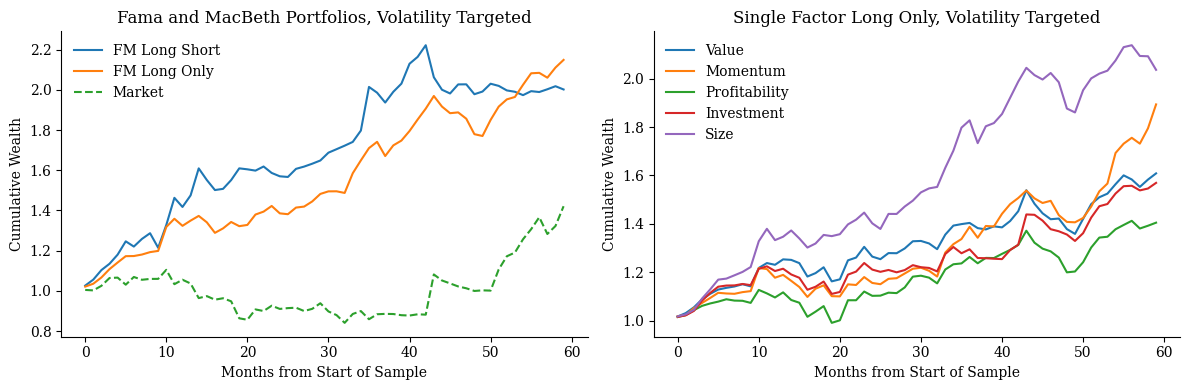

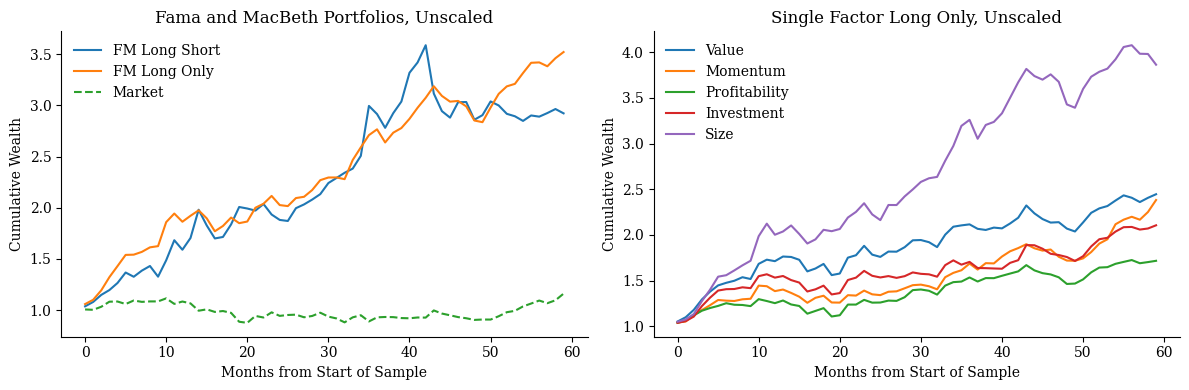

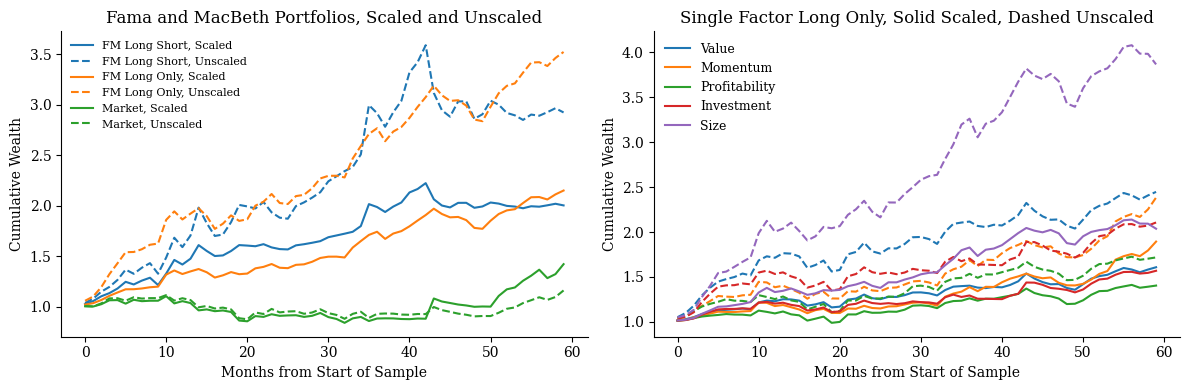

In [ ]:
plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'pdf.fonttype': 42,
})
factor_order = ['value', 'momentum', 'profitability', 'investment', 'size']
# figure 1, volatility targeted cumulative wealth
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

ax = axes[0]
ax.plot(np.cumprod(1 + fm_ls_scaled), label = 'FM Long Short')
ax.plot(np.cumprod(1 + fm_lo_scaled), label = 'FM Long Only')
ax.plot(np.cumprod(1 + market_scaled), label = 'Market', linestyle = '--')
ax.set_xlabel('Months from Start of Sample')
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Fama and MacBeth Portfolios, Volatility Targeted')
ax.legend(frameon = False)

ax = axes[1]
for factor in factor_order:
    if factor in factor_results:
        ax.plot(
            np.cumprod(1 + factor_results[factor]['returns_lo_scaled']),
            label = factor.title(),
        )
ax.set_xlabel('Months from Start of Sample')
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Single Factor Long Only, Volatility Targeted')
ax.legend(frameon = False)

fig.tight_layout()
fig.savefig(results_dir / 'ff_cumulative_scaled.pdf')
fig.savefig(results_dir / 'ff_cumulative_scaled.png')
plt.show()
plt.close(fig)


# figure 2, unscaled cumulative wealth

fig, axes = plt.subplots(1, 2, figsize = (12, 4))

ax = axes[0]
ax.plot(np.cumprod(1 + fm_ls_rets), label = 'FM Long Short')
ax.plot(np.cumprod(1 + fm_lo_rets), label = 'FM Long Only')
ax.plot(np.cumprod(1 + np.asarray(market_rets)), label = 'Market', linestyle = '--')
ax.set_xlabel('Months from Start of Sample')
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Fama and MacBeth Portfolios, Unscaled')
ax.legend(frameon = False)

ax = axes[1]
for factor in factor_order:
    if factor in factor_results:
        ax.plot(
            np.cumprod(1 + factor_results[factor]['returns_lo_unscaled']),
            label = factor.title(),
        )
ax.set_xlabel('Months')
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Single Factor Long Only, Unscaled')
ax.legend(frameon = False)

fig.tight_layout()
fig.savefig(results_dir / 'ff_cumulative_unscaled.pdf')
fig.savefig(results_dir / 'ff_cumulative_unscaled.png')
plt.show()
plt.close(fig)


# figure 3, volatility targeted against unscaled on the same axes.
# scaled and unscaled of the same strategy share a colour so that the pair
# is visually identifiable. the scaled line is solid and the unscaled is dashed.

fig, axes = plt.subplots(1, 2, figsize = (12, 4))

ax = axes[0]
ax.plot(np.cumprod(1 + fm_ls_scaled), label = 'FM Long Short, Scaled', color = 'C0')
ax.plot(np.cumprod(1 + fm_ls_rets), label = 'FM Long Short, Unscaled', color = 'C0', linestyle = '--')
ax.plot(np.cumprod(1 + fm_lo_scaled), label = 'FM Long Only, Scaled', color = 'C1')
ax.plot(np.cumprod(1 + fm_lo_rets), label = 'FM Long Only, Unscaled', color = 'C1', linestyle = '--')
ax.plot(np.cumprod(1 + market_scaled), label = 'Market, Scaled', color = 'C2')
ax.plot(np.cumprod(1 + np.asarray(market_rets)), label = 'Market, Unscaled', color = 'C2', linestyle = '--')
ax.set_xlabel('Months from Start of Sample')
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Fama and MacBeth Portfolios, Scaled and Unscaled')
ax.legend(frameon = False, fontsize = 8, loc = 'upper left')

ax = axes[1]
for k, factor in enumerate(factor_order):
    if factor in factor_results:
        col = f'C{k}'
        ax.plot(
            np.cumprod(1 + factor_results[factor]['returns_lo_scaled']),
            label = factor.title(),
            color = col,
        )
        ax.plot(
            np.cumprod(1 + factor_results[factor]['returns_lo_unscaled']),
            color = col,
            linestyle = '--',
        )
ax.set_xlabel('Month')
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Single Factor Long Only, Solid Scaled, Dashed Unscaled')
ax.legend(frameon = False, fontsize = 9, loc = 'upper left')

fig.tight_layout()
fig.savefig(results_dir / 'ff_cumulative_combined.pdf')
fig.savefig(results_dir / 'ff_cumulative_combined.png')
plt.show()
plt.close(fig)